# 004_strategy

## Purpose

This stage converts insights from the analysis stage into **tradable strategy signals**.

Using the standardized return data and detected shock events, we construct systematic rules that determine when positions should be opened across the cryptocurrency universe.

The objective is to transform the observed **lead–lag relationships between assets** into a structured trading signal that can be evaluated through backtesting.

---

## Inputs

This notebook reads artifacts generated in earlier stages of the pipeline.

Primary inputs:

- `returns_full.pkl` — synchronized daily return series for all assets  
- `z_scores.pkl` — standardized return series used to identify extreme movements  
- `event_bitmap.pkl` *(optional diagnostic)* — cross-asset shock structure from Stage 3

These datasets are loaded from:
* output/002_enrich/
* output/003_analysis/

---

## Analytical Goals

The strategy construction stage performs three main tasks:

### 1. Detect Shock Events

Identify statistically significant price movements using z-score thresholds.

### 2. Generate Trading Signals

Convert detected shock events into systematic trading signals across the asset universe.

### 3. Construct Position Matrices

Translate signals into time-aligned position matrices that represent the portfolio exposure through time.

These signals form the basis for the simulated trading strategy evaluated in the next stage.

---

## Outputs

Artifacts generated by this stage:

- `signals.pkl` — raw trading signal matrix  
- `positions.pkl` — position matrix representing active portfolio exposure  

These artifacts are written to:
* output/004_strategy/

and registered in the pipeline `manifest.pkl`.

---

## Design Principle

This stage follows several design principles to ensure reproducibility and clarity:

- **Deterministic pipeline** — signals are generated only from artifacts created in earlier stages.
- **Separation of concerns** — strategy construction is separated from backtesting logic.
- **Transparent signal construction** — each step from event detection to portfolio position is explicit.
- **Artifact persistence** — outputs are saved for inspection and reuse.

This structure keeps the strategy layer modular and reproducible within the overall 


### 1. Imports and Environment Setup
### Provide the necessary imports required for to to proceed.   

In [60]:
import pandas as pd
import numpy as np
import pickle
from datetime import datetime, UTC
import math
from pathlib import Path
import matplotlib.pyplot as plt

### 2. Prepare the environment for the notebook

In [61]:
startdate = "2023-01-01"
trading_days = 252
frequency = "1d"

universe = [
    "BTCUSDT",   # Bitcoin
    "ETHUSDT",   # Ethereum
    "BNBUSDT",   # Binance Coin
    "SOLUSDT",   # Solana
    "XRPUSDT",   # Ripple
    "ADAUSDT",   # Cardano
    "DOGEUSDT",  # Dogecoin
    "AVAXUSDT",  # Avalanche
    "LTCUSDT"    # Litecoin
]

execution_delay = [0, 1, 2, 3]
execution_cost_bps = [20, 30, 40]

stage_label = "004_strategy"

OUTPUT_ROOT = Path("../output")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

MANIFEST_FILE = OUTPUT_ROOT / "manifest.pkl"

DOWNLOAD_DIR = OUTPUT_ROOT / "001_download"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

ENRICH_DIR = OUTPUT_ROOT / "002_enrich"
ENRICH_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_DIR = OUTPUT_ROOT / "003_analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

STRATEGY_DIR = OUTPUT_ROOT / "004_strategy"
STRATEGY_DIR.mkdir(parents=True, exist_ok=True)

inspection_window = 20

sigma_threshold = 3

observation_window_length = 10
observation_window = range(1, observation_window_length + 1)

holding_period = 1


### 2.1 Loading the manifest pickle file

In [62]:
if MANIFEST_FILE.exists():
    manifest = pd.read_pickle(MANIFEST_FILE)
else:
    manifest = {}

manifest.setdefault(stage_label, {})

{'timestamp': '2026-03-14T09:43:43.461550+00:00',
 'artifacts': {'event_response_table': '../output/004_strategy/event_response_table.pkl',
  'leader_follower_summary': '../output/004_strategy/leader_follower_summary.pkl'},
 'rows_event_table': 216,
 'rows_pair_summary': 24}

### 3. Load the pickle files from the previous stage
We use these file contents for our analysis.

In [63]:

# 001_download artifacts
prices = pd.read_pickle(DOWNLOAD_DIR / "PRICES.pkl")
event_panels = {}
for coin in universe:
    panel_file = DOWNLOAD_DIR / f"{coin}.event_panel.pkl"
    event_panels[coin] = pd.read_pickle(panel_file)

# 002_enrich artifacts
returns_full = pd.read_pickle(ENRICH_DIR / "returns_full.pkl")
z_scores = pd.read_pickle(ENRICH_DIR / "z_scores.pkl")
rolling_sigma = pd.read_pickle(ENRICH_DIR / "rolling_sigma.pkl")
price_wide = pd.read_pickle(ENRICH_DIR / "price_wide.pkl")

# 003_analysis artifacts
event_bitmap = pd.read_pickle(ANALYSIS_DIR / "event_bitmap.pkl")
extreme_z_scores = pd.read_pickle(ANALYSIS_DIR / "extreme_z_scores.pkl")
sigma_event_matrix = pd.read_pickle(ANALYSIS_DIR / "sigma_event_matrix.pkl")

print("prices:", prices.shape)
print("returns_full:", returns_full.shape)
print("z_scores:", z_scores.shape)
print("rolling_sigma:", rolling_sigma.shape)
print("price_wide:", price_wide.shape)
print("event_bitmap:", event_bitmap.shape)
print("extreme_z_scores:", extreme_z_scores.shape)
print("sigma_event_matrix:", sigma_event_matrix.shape)
print("event panels loaded:", list(event_panels.keys()))

prices: (10327, 5)
returns_full: (974, 9)
z_scores: (955, 9)
rolling_sigma: (955, 9)
price_wide: (1169, 9)
event_bitmap: (19, 11)
extreme_z_scores: (9, 5)
sigma_event_matrix: (9, 5)
event panels loaded: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'LTCUSDT']


### 4. Review Shock Events

In [64]:
# signed z-score
z = z_scores.copy()

# magnitude
sigma_mag = np.abs(z)

# integer bucket
sigma_bucket = np.floor(sigma_mag).astype(int)

# cap extreme events
sigma_bucket = sigma_bucket.clip(upper=6)

# reapply sign
sigma_class = sigma_bucket * np.sign(z)

sigma_class = sigma_class.astype(int)

print("sigma class distribution:")
print(sigma_class.stack().value_counts().sort_index())

print()
print("sigma events per coin (|sigma| >= 1):")
print((sigma_class.abs() >= 1).sum())

print()
print("sigma distribution by coin:")

sigma_coin_dist = (
    sigma_class
        .stack()
        .reset_index(name="sigma")
        .pivot_table(
            index="coin",
            columns="sigma",
            aggfunc="size",
            fill_value=0
        )
        .sort_index(axis=1)
)

display(sigma_coin_dist)

print()
print("extreme shocks per coin (|sigma| >= 3):")
print((sigma_class.abs() >= 3).sum())

sigma class distribution:
-4       4
-3      40
-2     184
-1     877
 0    6228
 1     935
 2     267
 3      58
 4       2
Name: count, dtype: int64

sigma events per coin (|sigma| >= 1):
coin
ADAUSDT     269
AVAXUSDT    269
BNBUSDT     262
BTCUSDT     266
DOGEUSDT    250
ETHUSDT     266
LTCUSDT     248
SOLUSDT     293
XRPUSDT     244
dtype: int64

sigma distribution by coin:


sigma,-4,-3,-2,-1,0,1,2,3,4
coin,,,,,,,,,
ADAUSDT,0,6,16,109,686,102,33,2,1
AVAXUSDT,0,3,19,106,686,105,31,5,0
BNBUSDT,0,5,27,87,693,101,35,7,0
BTCUSDT,1,3,24,90,689,110,31,7,0
DOGEUSDT,0,3,21,90,705,100,28,8,0
ETHUSDT,1,5,22,101,689,104,26,6,1
LTCUSDT,0,7,19,94,707,98,22,8,0
SOLUSDT,0,3,18,107,662,127,33,5,0
XRPUSDT,2,5,18,93,711,88,28,10,0



extreme shocks per coin (|sigma| >= 3):
coin
ADAUSDT      9
AVAXUSDT     8
BNBUSDT     12
BTCUSDT     11
DOGEUSDT    11
ETHUSDT     13
LTCUSDT     15
SOLUSDT      8
XRPUSDT     17
dtype: int64


### 5. Build a sigma ledger

In [65]:
# build sigma ledger
sigma_ledger = (
    sigma_class
    .stack()
    .groupby([sigma_class.stack(), sigma_class.stack().index.get_level_values(1)])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

sigma_ledger.index.name = "SIGMA"

# totals across coins
sigma_ledger["TOTALS"] = sigma_ledger.sum(axis=1)

print("sigma ledger")
display(sigma_ledger)

print("\ncheck row totals (should match earlier totals):")
print(sigma_ledger["TOTALS"])

print("\ncheck column totals (should equal 955 days):")
print(sigma_ledger.drop(columns="TOTALS").sum(axis=0))

sigma ledger


coin,ADAUSDT,AVAXUSDT,BNBUSDT,BTCUSDT,DOGEUSDT,ETHUSDT,LTCUSDT,SOLUSDT,XRPUSDT,TOTALS
SIGMA,,,,,,,,,,
-4,0,0,0,1,0,1,0,0,2,4
-3,6,3,5,3,3,5,7,3,5,40
-2,16,19,27,24,21,22,19,18,18,184
-1,109,106,87,90,90,101,94,107,93,877
0,686,686,693,689,705,689,707,662,711,6228
1,102,105,101,110,100,104,98,127,88,935
2,33,31,35,31,28,26,22,33,28,267
3,2,5,7,7,8,6,8,5,10,58
4,1,0,0,0,0,1,0,0,0,2



check row totals (should match earlier totals):
SIGMA
-4       4
-3      40
-2     184
-1     877
 0    6228
 1     935
 2     267
 3      58
 4       2
Name: TOTALS, dtype: int64

check column totals (should equal 955 days):
coin
ADAUSDT     955
AVAXUSDT    955
BNBUSDT     955
BTCUSDT     955
DOGEUSDT    955
ETHUSDT     955
LTCUSDT     955
SOLUSDT     955
XRPUSDT     955
dtype: int64


### 6. Explore the direction of the leader coin and the folloer coins along with the vectors

In [66]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

WINDOW = 5
SHOCK_THRESHOLD = 3

events = []

dates = sigma_class.index
coins = sigma_class.columns

for i in range(len(dates) - WINDOW):

    event_date = dates[i]
    sigma_row = sigma_class.loc[event_date]

    # leader shocks
    leaders = sigma_row[sigma_row.abs() >= SHOCK_THRESHOLD]

    if leaders.empty:
        continue

    for r_coin, r_sigma in leaders.items():

        for t_coin in coins:

            if t_coin == r_coin:
                continue

            t_sigma = sigma_row[t_coin]

            # forward return vector
            vec = returns_full.loc[
                dates[i+1:i+WINDOW+1],
                t_coin
            ].round(3).tolist()

            events.append({
                "event_date": event_date,
                "r_coin": r_coin,
                "r_sigma": int(r_sigma),
                "t_coin": t_coin,
                "t_sigma": int(t_sigma),
                "act": "",          # placeholder for strategy later
                "t_vector": vec
            })

event_df = pd.DataFrame(events)

display(event_df.head(16))
print("rows:", len(event_df))

,event_date,r_coin,r_sigma,t_coin,t_sigma,act,t_vector
0,2023-08-17 00:00:00+00:00,ADAUSDT,-3,AVAXUSDT,-3,,"[0.025, -0.002, 0.006, -0.048, -0.019]"
1,2023-08-17 00:00:00+00:00,ADAUSDT,-3,BNBUSDT,-3,,"[-0.009, 0.002, -0.001, -0.028, 0.001]"
2,2023-08-17 00:00:00+00:00,ADAUSDT,-3,BTCUSDT,-4,,"[-0.021, 0.002, 0.003, -0.002, -0.003]"
3,2023-08-17 00:00:00+00:00,ADAUSDT,-3,DOGEUSDT,-2,,"[0.035, 0.011, 0.001, -0.022, 0.002]"
4,2023-08-17 00:00:00+00:00,ADAUSDT,-3,ETHUSDT,-4,,"[-0.012, 0.005, 0.009, -0.011, -0.02]"
5,2023-08-17 00:00:00+00:00,ADAUSDT,-3,LTCUSDT,-3,,"[-0.01, -0.0, 0.02, 0.026, -0.032]"
6,2023-08-17 00:00:00+00:00,ADAUSDT,-3,SOLUSDT,-1,,"[-0.018, 0.027, -0.005, -0.025, -0.031]"
7,2023-08-17 00:00:00+00:00,ADAUSDT,-3,XRPUSDT,-4,,"[-0.002, 0.028, 0.034, -0.025, -0.007]"
8,2023-08-17 00:00:00+00:00,AVAXUSDT,-3,ADAUSDT,-3,,"[0.032, 0.017, 0.009, -0.028, -0.018]"
9,2023-08-17 00:00:00+00:00,AVAXUSDT,-3,BNBUSDT,-3,,"[-0.009, 0.002, -0.001, -0.028, 0.001]"


rows: 832


### 6. These are the mover coins
There is an assumption the mover coins are the highert sigma values for a given day. 
It is important to note I have generalized to using alpha numeric sorting on the coins with equal sigmas and take the first.
Thus, the first highest sigma, lowers name sorting is our mover. To expand do this more rigorously:
* look at intraday prices
* look at a DAG of coins ( to see the branches of coins looking for affinity )
* look at trend lines for patterns in the prices ( attack, sustain, decay )

In [67]:
prime_movers = (
    event_df
    .loc[event_df.groupby("event_date")["r_sigma"].apply(lambda x: x.abs().idxmax())]
    [["event_date","r_coin","r_sigma"]]
    .rename(columns={"r_coin":"prime_coin","r_sigma":"prime_sigma"})
)

display(prime_movers.head(8))

,event_date,prime_coin,prime_sigma
24,2023-08-17 00:00:00+00:00,BTCUSDT,-4
56,2023-10-01 00:00:00+00:00,SOLUSDT,3
64,2023-10-23 00:00:00+00:00,BTCUSDT,3
80,2023-11-09 00:00:00+00:00,ETHUSDT,4
88,2023-11-10 00:00:00+00:00,AVAXUSDT,3
104,2023-11-11 00:00:00+00:00,AVAXUSDT,3
112,2023-11-15 00:00:00+00:00,BTCUSDT,3
120,2023-11-21 00:00:00+00:00,BNBUSDT,-3


### 7. this is diagnostic to see the breakdown of significant event signals per coin

In [68]:
sigma_breakdown = (
    prime_movers
    .groupby(["prime_coin","prime_sigma"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

display(sigma_breakdown)

prime_sigma,-4,-3,3,4
prime_coin,,,,
ADAUSDT,0,4,2,1
AVAXUSDT,0,0,4,0
BNBUSDT,0,2,7,0
BTCUSDT,1,2,6,0
DOGEUSDT,0,0,5,0
ETHUSDT,0,1,3,1
LTCUSDT,0,2,6,0
SOLUSDT,0,0,2,0
XRPUSDT,1,2,6,0


### 8. this is a diagnostic to see the collection of coins for a given event. "what do the followers do?"

In [69]:
leader_view = (
    prime_movers
    .rename(columns={"prime_coin":"leader","prime_sigma":"leader_sigma"})
    .merge(
        event_df
        .groupby(["event_date","r_coin"])["r_sigma"]
        .first()
        .unstack(),
        on="event_date",
        how="left"
    )
    .drop(columns="event_date")
)

display(leader_view)

,leader,leader_sigma,ADAUSDT,AVAXUSDT,BNBUSDT,BTCUSDT,DOGEUSDT,ETHUSDT,LTCUSDT,SOLUSDT,XRPUSDT
0,BTCUSDT,-4,-3.0,-3.0,-3.0,-4.0,NaN,-4.0,-3.0,NaN,-4.0
1,SOLUSDT,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN
2,BTCUSDT,3,NaN,NaN,NaN,3.0,3.0,NaN,NaN,NaN,NaN
3,ETHUSDT,4,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN
4,AVAXUSDT,3,NaN,3.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN
5,AVAXUSDT,3,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,BTCUSDT,3,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
7,BNBUSDT,-3,NaN,NaN,-3.0,NaN,NaN,NaN,NaN,NaN,NaN
8,ADAUSDT,3,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,BNBUSDT,3,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN


### 9. build on the previous cell and filter out where NaN is 3 or less. 
where we have majority movement in high sigmas and that see the majority of the cohort moving.

In [70]:
sigma_cols = leader_view.columns[2:]

filtered_events = (
    leader_view
    .assign(n_movers=leader_view[sigma_cols].notna().sum(axis=1))
    .loc[lambda df: df[sigma_cols].isna().sum(axis=1) <= 3]   # ≤3 NaNs → majority moved
)

display(filtered_events)

,leader,leader_sigma,ADAUSDT,AVAXUSDT,BNBUSDT,BTCUSDT,DOGEUSDT,ETHUSDT,LTCUSDT,SOLUSDT,XRPUSDT,n_movers
0,BTCUSDT,-4,-3.0,-3.0,-3.0,-4.0,NaN,-4.0,-3.0,NaN,-4.0,7
45,ADAUSDT,3,3.0,3.0,NaN,NaN,3.0,3.0,NaN,3.0,3.0,6
57,XRPUSDT,-4,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0,-3.0,-4.0,9


### 10. build on the previous cell and filter out where NaN is 3 to 5 less. 
where we have majority movement in high sigmas and that see smaller clusters. 
we are not looking at the NaN count that is 1 or 2 as that is singleton movement for now. 
what would be interesting later is look at affinities with specific coins.

In [71]:
sigma_cols = leader_view.columns[2:]

mid_events = (
    leader_view
    .assign(n_movers=leader_view[sigma_cols].notna().sum(axis=1))
    .loc[lambda df: df["n_movers"].between(3,5)]
)

display(mid_events)

,leader,leader_sigma,ADAUSDT,AVAXUSDT,BNBUSDT,BTCUSDT,DOGEUSDT,ETHUSDT,LTCUSDT,SOLUSDT,XRPUSDT,n_movers
20,AVAXUSDT,3,NaN,3.0,NaN,NaN,NaN,NaN,3.0,NaN,3.0,3
27,ADAUSDT,-3,-3.0,NaN,-3.0,NaN,NaN,-3.0,NaN,NaN,-3.0,4
41,BTCUSDT,-3,NaN,NaN,NaN,-3.0,-3.0,-3.0,NaN,-3.0,NaN,4
42,ADAUSDT,4,4.0,NaN,NaN,3.0,NaN,NaN,NaN,3.0,3.0,4
43,ADAUSDT,-3,-3.0,NaN,NaN,NaN,NaN,-3.0,-3.0,NaN,NaN,3
51,ADAUSDT,-3,-3.0,-3.0,NaN,NaN,-3.0,NaN,-3.0,NaN,-3.0,5


### 11. Validate the shape of the data

In [72]:
print("event_df event_date dtype:", event_df["event_date"].dtype)
print("mid_events index dtype:", mid_events.index.dtype)

print("\nSample event_df dates:")
print(event_df["event_date"].head())

print("\nSample mid_events index:")
print(mid_events.index[:5])

event_df event_date dtype: datetime64[ns, UTC]
mid_events index dtype: int64

Sample event_df dates:
0   2023-08-17 00:00:00+00:00
1   2023-08-17 00:00:00+00:00
2   2023-08-17 00:00:00+00:00
3   2023-08-17 00:00:00+00:00
4   2023-08-17 00:00:00+00:00
Name: event_date, dtype: datetime64[ns, UTC]

Sample mid_events index:
Index([20, 27, 41, 42, 43], dtype='int64')


### 12. Start assembling the vectors, ensuring we have the ability to build out t1, t3, and t5 sums later

In [73]:
# remove any existing lag columns
cluster_events = cluster_events.drop(
    columns=[c for c in cluster_events.columns if c.startswith("t") and c[1:].isdigit()],
    errors="ignore"
)

lags = pd.DataFrame(
    cluster_events["t_vector"].tolist(),
    columns=[f"t{i+1}" for i in range(len(cluster_events["t_vector"].iloc[0]))]
)

cluster_events_shape = pd.concat(
    [cluster_events.reset_index(drop=True), lags],
    axis=1
)

display(cluster_events_shape.head())
print("shape:", cluster_events_shape.shape)

,event_date,r_coin,r_sigma,t_coin,t_sigma,act,t_vector,leader,leader_sigma,t1,t2,t3,t4,t5
0,2023-08-17 00:00:00+00:00,ADAUSDT,-3,AVAXUSDT,-3,,"[0.025, -0.002, 0.006, -0.048, -0.019]",ADAUSDT,-3,0.025,-0.002,0.006,-0.048,-0.019
1,2023-08-17 00:00:00+00:00,ADAUSDT,-3,AVAXUSDT,-3,,"[0.025, -0.002, 0.006, -0.048, -0.019]",ADAUSDT,-3,0.025,-0.002,0.006,-0.048,-0.019
2,2023-08-17 00:00:00+00:00,ADAUSDT,-3,AVAXUSDT,-3,,"[0.025, -0.002, 0.006, -0.048, -0.019]",ADAUSDT,-3,0.025,-0.002,0.006,-0.048,-0.019
3,2023-08-17 00:00:00+00:00,ADAUSDT,-3,BNBUSDT,-3,,"[-0.009, 0.002, -0.001, -0.028, 0.001]",ADAUSDT,-3,-0.009,0.002,-0.001,-0.028,0.001
4,2023-08-17 00:00:00+00:00,ADAUSDT,-3,BNBUSDT,-3,,"[-0.009, 0.002, -0.001, -0.028, 0.001]",ADAUSDT,-3,-0.009,0.002,-0.001,-0.028,0.001


shape: (216, 14)


### 13. Plot a sample response of a follower and a leader. 

Plotting: ADAUSDT → AVAXUSDT


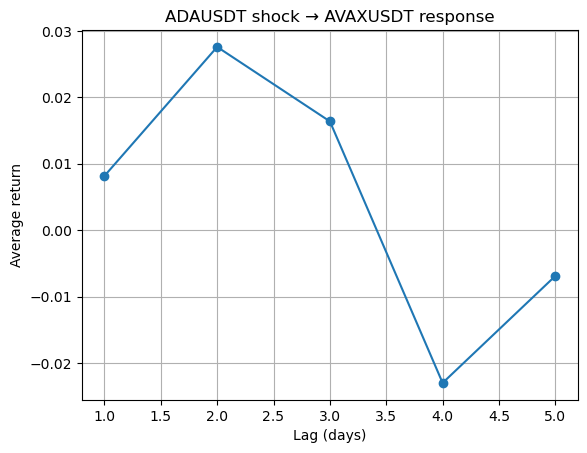

In [74]:
# pick the pair with the most observations
pair = cluster_events_shape.groupby(["r_coin","t_coin"]).size().idxmax()
leader, follower = pair

print("Plotting:", leader, "→", follower)

subset = cluster_events_shape[
    (cluster_events_shape["r_coin"] == leader) &
    (cluster_events_shape["t_coin"] == follower)
]

lag_cols = ["t1","t2","t3","t4","t5"]

curve = subset[lag_cols].mean()

plt.figure()
plt.plot(range(1,6), curve.values, marker="o")
plt.xlabel("Lag (days)")
plt.ylabel("Average return")
plt.title(f"{leader} shock → {follower} response")
plt.grid(True)

plt.show()

### 14. Add the t1, t3, and t5 sums to see what type of shape we get. Enriching the plots.

In [75]:
cluster_events_shape["t1sum"] = cluster_events_shape["t1"]

cluster_events_shape["t3sum"] = (
    cluster_events_shape[["t1", "t2", "t3"]].sum(axis=1)
)

cluster_events_shape["t5sum"] = (
    cluster_events_shape[["t1", "t2", "t3", "t4", "t5"]].sum(axis=1)
)

display(
    cluster_events_shape[
        ["r_coin","t_coin","t1","t2","t3","t4","t5","t1sum","t3sum","t5sum"]
    ].head(32)
)

,r_coin,t_coin,t1,t2,t3,t4,t5,t1sum,t3sum,t5sum
0,ADAUSDT,AVAXUSDT,0.025,-0.002,0.006,-0.048,-0.019,0.025,0.029,-0.038
1,ADAUSDT,AVAXUSDT,0.025,-0.002,0.006,-0.048,-0.019,0.025,0.029,-0.038
2,ADAUSDT,AVAXUSDT,0.025,-0.002,0.006,-0.048,-0.019,0.025,0.029,-0.038
3,ADAUSDT,BNBUSDT,-0.009,0.002,-0.001,-0.028,0.001,-0.009,-0.008,-0.035
4,ADAUSDT,BNBUSDT,-0.009,0.002,-0.001,-0.028,0.001,-0.009,-0.008,-0.035
5,ADAUSDT,BNBUSDT,-0.009,0.002,-0.001,-0.028,0.001,-0.009,-0.008,-0.035
6,ADAUSDT,BTCUSDT,-0.021,0.002,0.003,-0.002,-0.003,-0.021,-0.016,-0.021
7,ADAUSDT,BTCUSDT,-0.021,0.002,0.003,-0.002,-0.003,-0.021,-0.016,-0.021
8,ADAUSDT,BTCUSDT,-0.021,0.002,0.003,-0.002,-0.003,-0.021,-0.016,-0.021
9,ADAUSDT,DOGEUSDT,0.035,0.011,0.001,-0.022,0.002,0.035,0.047,0.027


### 15. Plot the lag information of the followers to better have a sense of the activity
This is also an example, since the data would be for all of the events x each follower.
For brevity, we are only showing the first 24 items.

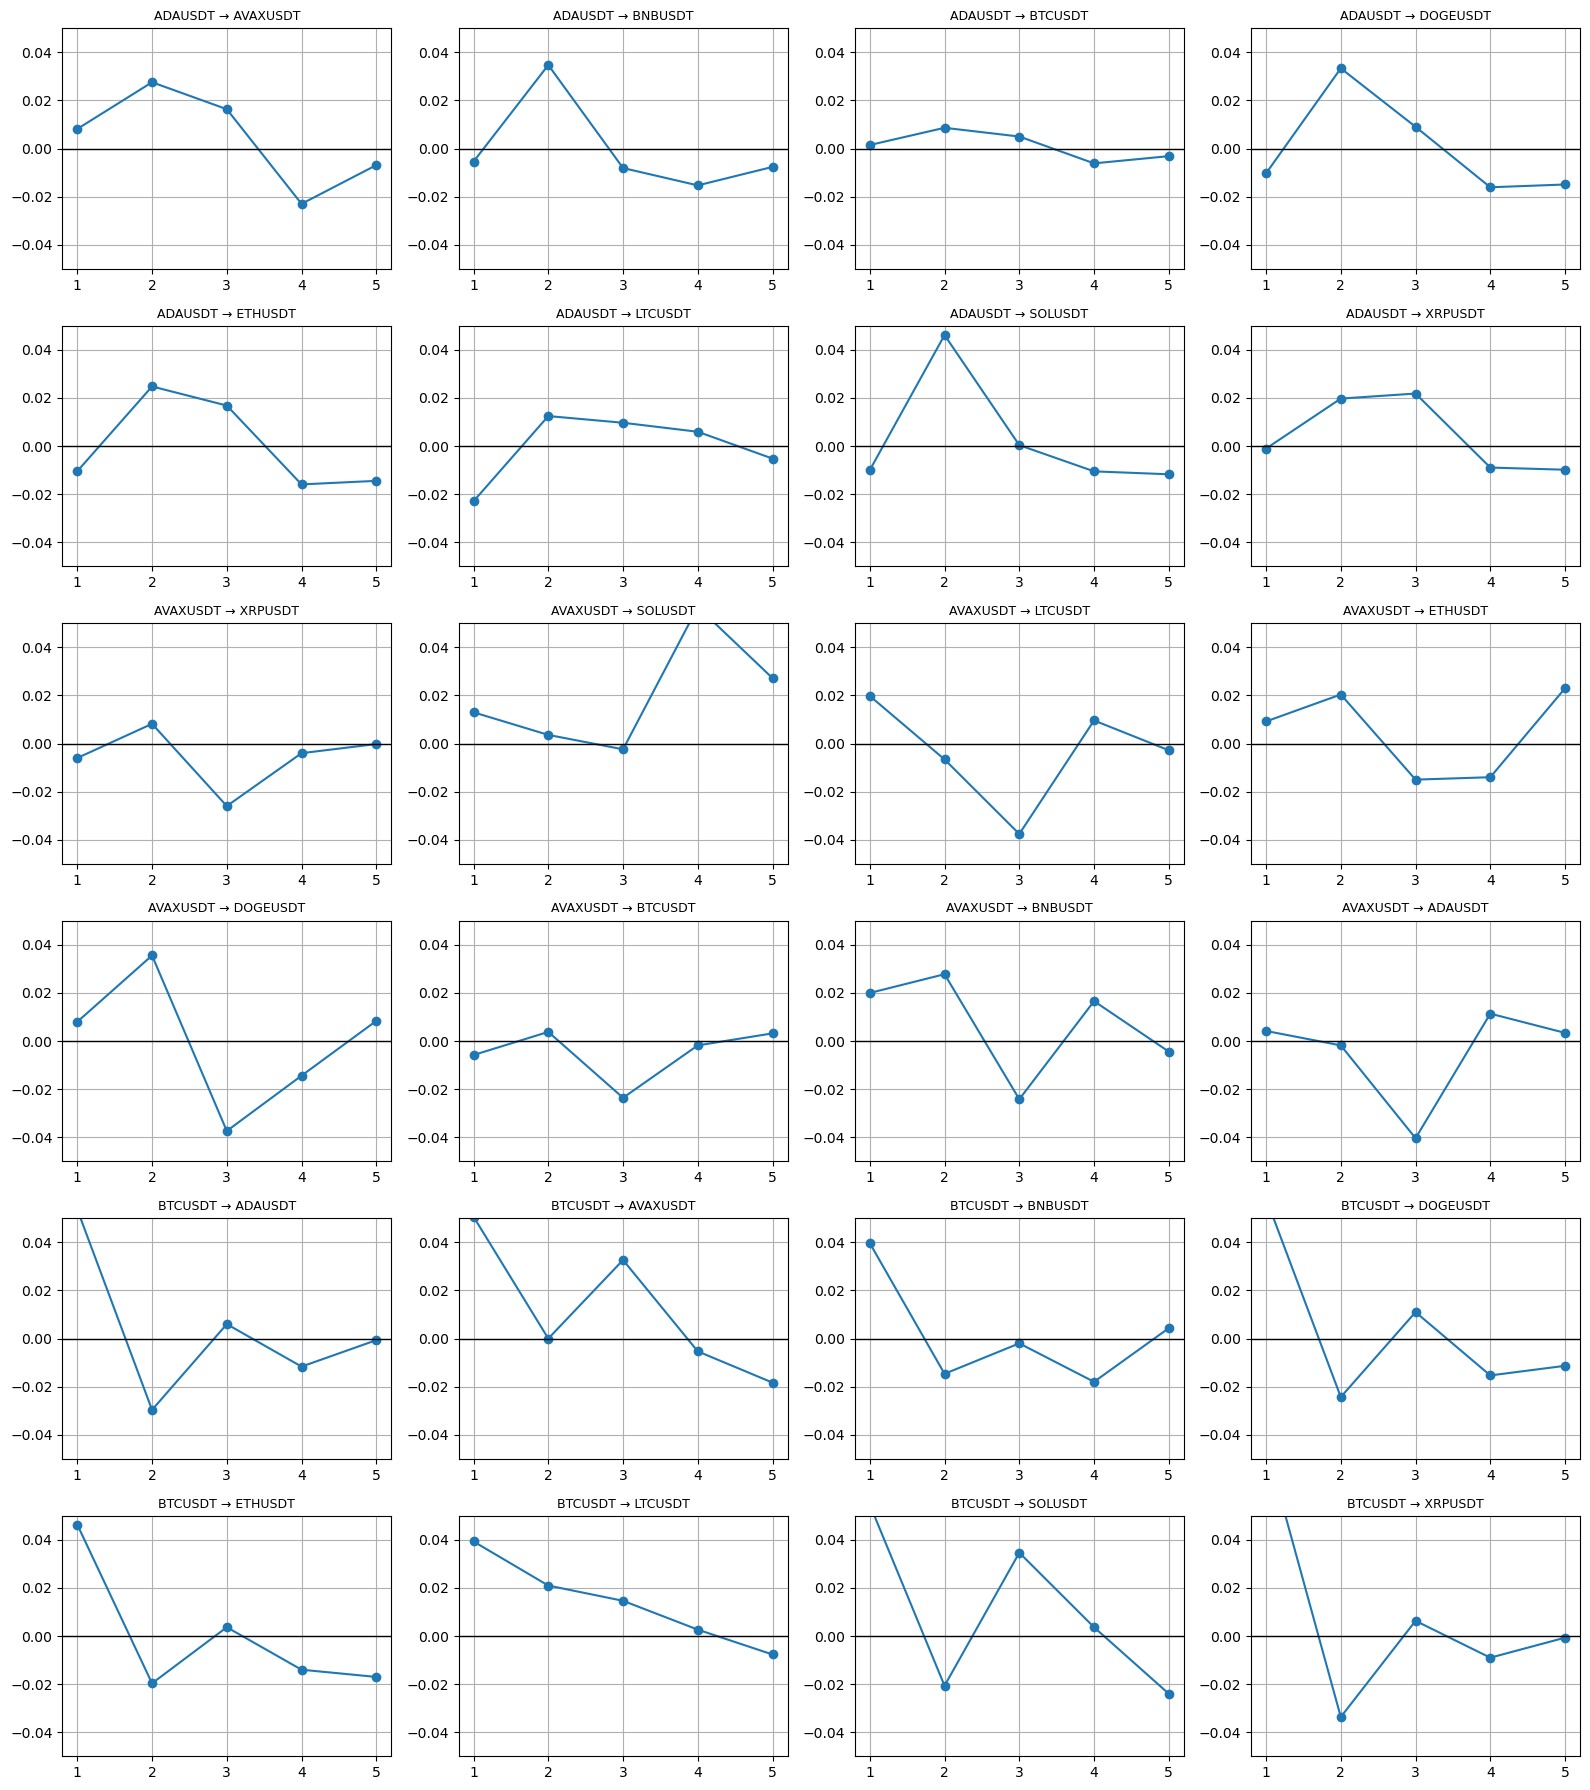

In [76]:
import matplotlib.pyplot as plt

lag_cols = ["t1","t2","t3","t4","t5"]

# get top 24 leader→follower pairs by observation count
pairs = (
    cluster_events_shape
    .groupby(["r_coin","t_coin"])
    .size()
    .sort_values(ascending=False)
    .head(24)
    .index
)

fig, axes = plt.subplots(6, 4, figsize=(16,18))
axes = axes.flatten()

for i, (leader, follower) in enumerate(pairs):

    subset = cluster_events_shape[
        (cluster_events_shape["r_coin"] == leader) &
        (cluster_events_shape["t_coin"] == follower)
    ]

    curve = subset[lag_cols].mean()

    ax = axes[i]

    ax.plot(range(1,6), curve.values, marker="o")
    ax.axhline(0, color="black", linewidth=1)

    ax.set_title(f"{leader} → {follower}", fontsize=9)
    ax.set_xticks(range(1,6))
    ax.set_ylim(-0.05,0.05)

    ax.grid(True)

plt.tight_layout()
plt.show()

### 999. Persist the artifacts

In [77]:

EVENT_RESPONSE_FILE = STRATEGY_DIR / "event_response_table.pkl"
PAIR_SUMMARY_FILE   = STRATEGY_DIR / "leader_follower_summary.pkl"

cluster_events_shape.to_pickle(EVENT_RESPONSE_FILE)

print("saved:", EVENT_RESPONSE_FILE)

pair_summary = (
    cluster_events_shape
    .groupby(["r_coin","t_coin"])
    .agg(
        n_events=("t1","size"),
        t1_mean=("t1","mean"),
        t3sum_mean=("t3sum","mean"),
        t5sum_mean=("t5sum","mean")
    )
    .reset_index()
)

pair_summary.to_pickle(PAIR_SUMMARY_FILE)

print("saved:", PAIR_SUMMARY_FILE)

if MANIFEST_FILE.exists():
    manifest = pd.read_pickle(MANIFEST_FILE)
else:
    manifest = {}

manifest.setdefault(stage_label, {})

manifest[stage_label] = {
    "timestamp": datetime.now(UTC).isoformat(),
    "artifacts": {
        "event_response_table": str(EVENT_RESPONSE_FILE),
        "leader_follower_summary": str(PAIR_SUMMARY_FILE)
    },
    "rows_event_table": len(cluster_events_shape),
    "rows_pair_summary": len(pair_summary)
}

pd.to_pickle(manifest, MANIFEST_FILE)

print("manifest updated:", MANIFEST_FILE)

saved: ../output/004_strategy/event_response_table.pkl
saved: ../output/004_strategy/leader_follower_summary.pkl
manifest updated: ../output/manifest.pkl
